<a href="https://colab.research.google.com/github/Nizamuddin1N/AI_Email_Spam_Dectection/blob/main/AI_Spam_Email_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB

import seaborn as sns
import matplotlib.pyplot as plt

nltk.download("stopwords")

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                              text label
0                    Win money now  spam
1            Lowest price pharmacy  spam
2                   Hi how are you   ham
3              Let's meet tomorrow   ham
4            Claim your free prize  spam
5   Important update about account   ham
6            Cheap loans available  spam
7             Project meeting at 5   ham
8  Congratulations you won lottery  spam
9                  Dinner tonight?   ham
                              text label                clean_text
0                    Win money now  spam                 win money
1            Lowest price pharmacy  spam     lowest price pharmacy
2                   Hi how are you   ham                        hi
3              Let's meet tomorrow   ham         let meet tomorrow
4            Claim your free prize  spam          claim free prize
5   Important update about account   ham  important update account
6            Cheap loans available  spam     cheap loans available
7            

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


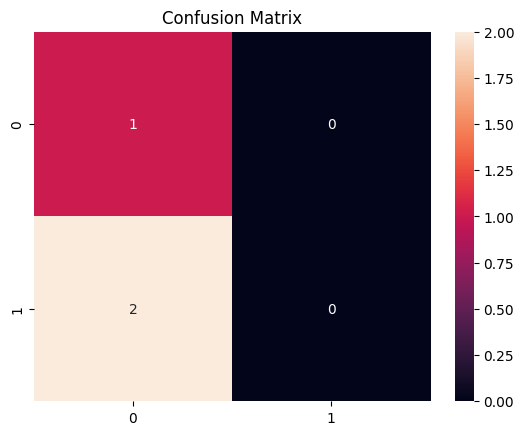

Test your own message
Enter message: Hi, i am nizamuddin. I am looking for internship.
Prediction: ham


In [ ]:
data = {
"text":[
"Win money now",
"Lowest price pharmacy",
"Hi how are you",
"Let's meet tomorrow",
"Claim your free prize",
"Important update about account",
"Cheap loans available",
"Project meeting at 5",
"Congratulations you won lottery",
"Dinner tonight?"
],
"label":[
"spam",
"spam",
"ham",
"ham",
"spam",
"ham",
"spam",
"ham",
"spam",
"ham"
]
}

df = pd.DataFrame(data)

print(df)

stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    text = re.sub("[^a-zA-Z]"," ",text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(preprocess)

print(df)

X = df["clean_text"]
y = df["label"]

vectorizer = TfidfVectorizer()

X_vector = vectorizer.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X_vector,y,test_size=0.3,random_state=42
)

model = MultinomialNB()

model.fit(X_train,y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

print("Accuracy:",accuracy)

print(classification_report(y_test,pred))

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

print("Test your own message")

msg = input("Enter message: ")

msg = preprocess(msg)

msg_vec = vectorizer.transform([msg])

prediction = model.predict(msg_vec)

print("Prediction:",prediction[0])